In [ ]:
import json
#open analysis_results.json
with open('analysis_results.json', 'r') as f:
    data_all = json.load(f)
data_all


In [ ]:
import random
data = random.sample(data_all, 20)

In [ ]:
data  = data_all[331]

In [ ]:
data

In [ ]:
import PIL.Image as Image
input = Image.open(data["local_input_image"])
outpt = Image.open(data["output_image"])

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(input)
plt.subplot(1, 2, 2)
plt.imshow(outpt)
plt.show()

In [ ]:
# 统计 analysis 字段中的各项分布
from collections import Counter

# 统计 action 的分布
actions = [item['analysis']['action'] for item in data_all if 'analysis' in item and 'action' in item['analysis']]
action_counts = Counter(actions)

# 统计 object_name 的分布(排除 INVALID)
object_names = [item['analysis']['object_name'] for item in data_all 
                if 'analysis' in item 
                and 'object_name' in item['analysis']
                and 'INVALID' not in item['analysis']['object_name']]
object_name_counts = Counter(object_names)

# 统计 confidence_score 的分布
confidence_scores = [item['analysis']['confidence_score'] for item in data_all if 'analysis' in item and 'confidence_score' in item['analysis']]
confidence_score_counts = Counter(confidence_scores)

print("=== Action 分布 ===")
for action, count in action_counts.most_common():
    print(f"{action}: {count} ({count/len(actions)*100:.2f}%)")

print(f"\n=== Object Name 分布 (Top 30, 排除 INVALID) ===")
for obj_name, count in object_name_counts.most_common(30):
    print(f"{obj_name}: {count} ({count/len(object_names)*100:.2f}%)")

print(f"\n=== Confidence Score 分布 ===")
for score, count in sorted(confidence_score_counts.items()):
    print(f"分数 {score}: {count} ({count/len(confidence_scores)*100:.2f}%)")

print(f"\n=== 总计 ===")
print(f"总样本数: {len(data_all)}")
print(f"有 analysis 字段的样本数: {len([item for item in data_all if 'analysis' in item])}")
print(f"有 action 字段的样本数: {len(actions)}")
print(f"有 object_name 字段的样本数(排除 INVALID): {len(object_names)}")
print(f"有 confidence_score 字段的样本数: {len(confidence_scores)}")

In [5]:
# 统计除去 INVALID 后的 object_name 数量
total_with_object_name = len([item for item in data_all 
                               if 'analysis' in item 
                               and 'object_name' in item['analysis']])

valid_object_names = len([item for item in data_all 
                          if 'analysis' in item 
                          and 'object_name' in item['analysis']
                          and 'INVALID' not in item['analysis']['object_name']])

invalid_count = total_with_object_name - valid_object_names

print(f"总共有 object_name 字段的样本: {total_with_object_name}")
print(f"INVALID 的数量: {invalid_count} ({invalid_count/total_with_object_name*100:.2f}%)")
print(f"除去 INVALID 后剩余的有效 object_name: {valid_object_names} ({valid_object_names/total_with_object_name*100:.2f}%)")
print(f"\n有效 object_name 的唯一值数量: {len(object_name_counts)}")

总共有 object_name 字段的样本: 257553
INVALID 的数量: 173738 (67.46%)
除去 INVALID 后剩余的有效 object_name: 83815 (32.54%)

有效 object_name 的唯一值数量: 39174


In [9]:
sample

{'open_image_input_url': 'https://c2.staticflickr.com/1/32/59082525_55d86fc788_o.jpg',
 'text': "Transform the maid's outfit on the left into an elegant, knee-length black velvet cocktail dress with delicate silver embroidery, ensuring the fabric texture is realistic under the dim party lighting, while subtly changing the nurse's light green top to a rich, deep sapphire blue satin, maintaining the shiny finish and keeping the overall composition and expressions consistent.",
 'output_image': 'openimages/edited/sft/kew9vb_retry2.png',
 'edit_type': 'Clothing edit (change color/outfit)',
 'summarized_text': "Add an elegant black velvet cocktail dress with silver embroidery to the maid, and change the nurse's light green top to deep sapphire blue satin.",
 'local_input_image': 'openimages/source/train_0/03db95a08ab8cbc9.jpg',
 'analysis': {'action': 'replace',
  'object_name': "[[OBJECT_NAME:maid's outfit]]",
  'confidence_score': 8}}

随机样本信息:
Object Name: [[OBJECT_NAME:soft, white, damp compress]]
Action: replace
Confidence Score: 9

Prompt: N/A

输入图片: openimages/source/train_0/06ae8877b17a957d.jpg
输出图片: openimages/edited/sft/80555.png


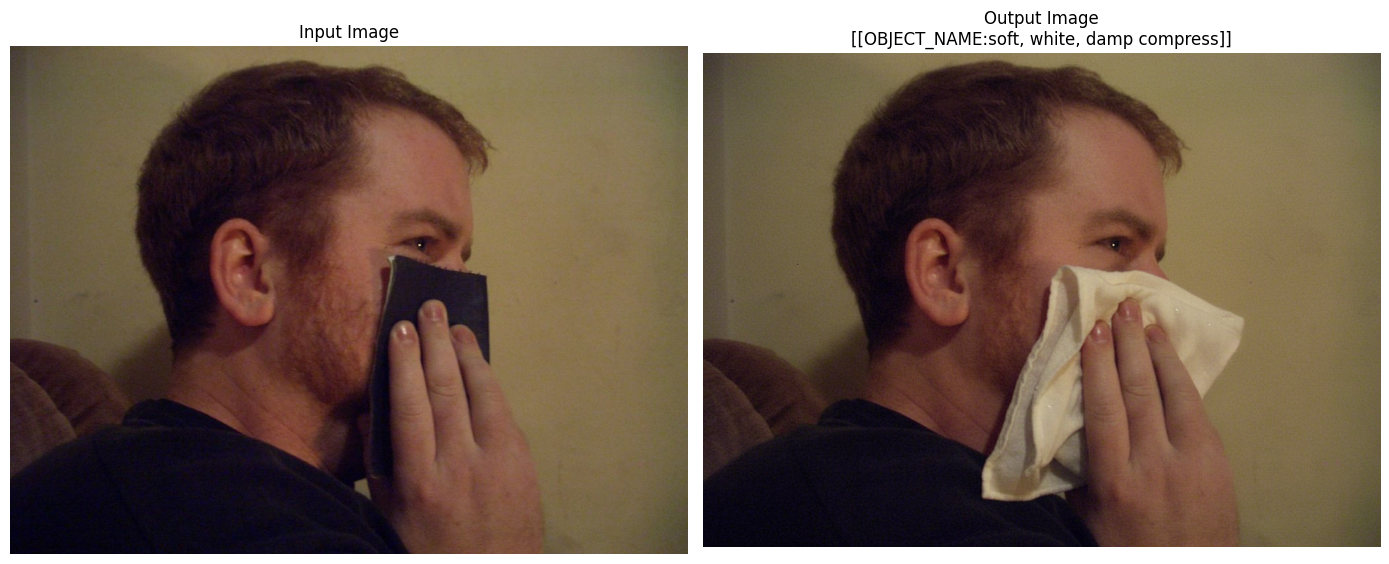

Prompt: Replace the dark rectangular object the man is holding to his face with a soft, white, damp compress, ensuring the new object's texture and moisture are realistically rendered, and its lighting subtly matches the low-light ambiance of the original scene while the man's fingers naturally conform to its form.


In [22]:
# 随机显示有效 object_name 的样本
import random

valid_samples = [item for item in data_all 
                 if 'analysis' in item 
                 and 'object_name' in item['analysis']
                 and 'INVALID' not in item['analysis']['object_name']]

# 随机选择一个样本
sample = random.choice(valid_samples)

print(f"随机样本信息:")
print(f"Object Name: {sample['analysis']['object_name']}")
print(f"Action: {sample['analysis'].get('action', 'N/A')}")
print(f"Confidence Score: {sample['analysis'].get('confidence_score', 'N/A')}")
print(f"\nPrompt: {sample.get('prompt', 'N/A')}")
print(f"\n输入图片: {sample.get('local_input_image', 'N/A')}")
print(f"输出图片: {sample.get('output_image', 'N/A')}")

# 显示图片
if 'local_input_image' in sample and 'output_image' in sample:
    import PIL.Image as Image
    import matplotlib.pyplot as plt
    
    input_img = Image.open(sample["local_input_image"])
    output_img = Image.open(sample["output_image"])
    
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(input_img)
    plt.title('Input Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title(f'Output Image\n{sample["analysis"]["object_name"]}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
print(f'Prompt: {sample.get( "text", "N/A")}') 

In [ ]:
# 可视化分布
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Action 分布
ax1 = axes[0, 0]
action_data = action_counts.most_common()
actions_list = [a[0] for a in action_data]
counts_list = [a[1] for a in action_data]
ax1.bar(range(len(actions_list)), counts_list, color='skyblue')
ax1.set_xticks(range(len(actions_list)))
ax1.set_xticklabels(actions_list, rotation=45, ha='right')
ax1.set_ylabel('Count')
ax1.set_title('Action Distribution')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(counts_list):
    ax1.text(i, v, f'{v}\n({v/len(actions)*100:.1f}%)', ha='center', va='bottom', fontsize=8)

# 2. Confidence Score 分布
ax2 = axes[0, 1]
score_data = sorted(confidence_score_counts.items())
scores = [s[0] for s in score_data]
score_counts = [s[1] for s in score_data]
ax2.bar(scores, score_counts, color='lightcoral')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Count')
ax2.set_title('Confidence Score Distribution')
ax2.grid(axis='y', alpha=0.3)
for i, (score, count) in enumerate(zip(scores, score_counts)):
    if count > 1000:  # 只标注较大的值
        ax2.text(score, count, f'{count}\n({count/len(confidence_scores)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=8)

# 3. Top 15 Object Names (排除 INVALID)
ax3 = axes[1, 0]
valid_objects = [(obj, count) for obj, count in object_name_counts.most_common() 
                  if 'INVALID' not in obj][:15]
obj_names = [o[0].replace('[[OBJECT_NAME:', '').replace(']]', '') for o in valid_objects]
obj_counts = [o[1] for o in valid_objects]
ax3.barh(range(len(obj_names)), obj_counts, color='lightgreen')
ax3.set_yticks(range(len(obj_names)))
ax3.set_yticklabels(obj_names, fontsize=9)
ax3.set_xlabel('Count')
ax3.set_title('Top 15 Object Names (excluding INVALID)')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()
for i, v in enumerate(obj_counts):
    ax3.text(v, i, f' {v}', va='center', fontsize=8)

# 4. Action vs Confidence Score 热力图
ax4 = axes[1, 1]
# 创建 action 和 confidence score 的组合统计
action_confidence = {}
for item in data_all:
    if 'analysis' in item and 'action' in item['analysis'] and 'confidence_score' in item['analysis']:
        action = item['analysis']['action']
        score = item['analysis']['confidence_score']
        if action not in action_confidence:
            action_confidence[action] = {}
        if score not in action_confidence[action]:
            action_confidence[action][score] = 0
        action_confidence[action][score] += 1

# 准备热力图数据
unique_actions = sorted(action_confidence.keys())[:10]  # 只取前10个action
unique_scores = sorted(set(score for action in action_confidence.values() for score in action.keys()))
heatmap_data = []
for action in unique_actions:
    row = [action_confidence[action].get(score, 0) for score in unique_scores]
    heatmap_data.append(row)

im = ax4.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax4.set_xticks(range(len(unique_scores)))
ax4.set_xticklabels(unique_scores)
ax4.set_yticks(range(len(unique_actions)))
ax4.set_yticklabels(unique_actions)
ax4.set_xlabel('Confidence Score')
ax4.set_ylabel('Action')
ax4.set_title('Action vs Confidence Score Heatmap')
plt.colorbar(im, ax=ax4, label='Count')

plt.tight_layout()
plt.savefig('analysis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("图表已保存为 analysis_distribution.png")